# 🏋️ Step 3 — Model Training

**Protein Function Prediction Using Genomic Language Model (ESM-2)**

Defines the classifier model, trains it with focal loss + early stopping, and saves the best checkpoint.

In [1]:
import os, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, roc_auc_score, hamming_loss
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# ─── Configuration ───
PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'results', 'models')
METRICS_DIR = os.path.join(PROJECT_ROOT, 'results', 'metrics')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'plots')
for d in [MODELS_DIR, METRICS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Hyperparameters
EMBEDDING_DIM = 320
HIDDEN_DIMS = [512, 256]
DROPOUT = 0.3
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 50
BATCH_SIZE = 32
PATIENCE = 8
GRADIENT_CLIP = 1.0
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.25
SEED = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.style.use('dark_background')
COLORS = ['#00D4FF', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A855F7', '#F97316']

print(f'🖥️  Device  : {DEVICE}')
print(f'📊 Epochs  : {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LR}')

🖥️  Device  : cpu
📊 Epochs  : 50, Batch: 32, LR: 0.001


## 3.1 — Model Definition

In [2]:
class FocalLoss(nn.Module):
    """Binary Focal Loss for multi-label classification."""
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        ce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal = (1 - p_t) ** self.gamma
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * focal * ce).mean()


class ResidualBlock(nn.Module):
    """Linear → BatchNorm → GELU → Dropout with skip connection."""
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.skip = (in_dim == out_dim)
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        out = self.block(x)
        return out + x if self.skip else out


class ProteinFunctionClassifier(nn.Module):
    """MLP classifier on ESM-2 embeddings → multi-label GO term predictions."""
    def __init__(self, input_dim, hidden_dims, num_labels, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(ResidualBlock(prev, h, dropout))
            prev = h
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev, num_labels)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))

    def predict_proba(self, x):
        return torch.sigmoid(self.forward(x))


class ProteinDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.X = torch.FloatTensor(embeddings)
        self.y = torch.FloatTensor(labels)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


print('✅ Model classes defined')

✅ Model classes defined


## 3.2 — Load Data

In [3]:
X_train = np.load(os.path.join(PROCESSED_DIR, 'embeddings_train.npy'))
X_val   = np.load(os.path.join(PROCESSED_DIR, 'embeddings_val.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'labels_train.npy'))
y_val   = np.load(os.path.join(PROCESSED_DIR, 'labels_val.npy'))

num_labels = y_train.shape[1]
print(f'📊 Train: {X_train.shape}, Val: {X_val.shape}, Labels: {num_labels}')

train_loader = DataLoader(ProteinDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(ProteinDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

📊 Train: (56, 320), Val: (8, 320), Labels: 4


## 3.3 — Initialize & Train

In [4]:
model = ProteinFunctionClassifier(EMBEDDING_DIM, HIDDEN_DIMS, num_labels, DROPOUT).to(DEVICE)
criterion = FocalLoss(FOCAL_GAMMA, FOCAL_ALPHA)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'🧠 Parameters: {params:,}')
print(model)

🧠 Parameters: 298,244
ProteinFunctionClassifier(
  (features): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=320, out_features=512, bias=True)
        (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.3, inplace=False)
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=512, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=256, out_features=4, bias=True)
)


In [5]:
def eval_model(model, loader):
    model.eval()
    loss_sum, preds_all, labels_all = 0, [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss_sum += criterion(logits, yb).item() * len(xb)
            preds_all.append(torch.sigmoid(logits).cpu().numpy())
            labels_all.append(yb.cpu().numpy())
    preds = np.concatenate(preds_all)
    labels = np.concatenate(labels_all)
    binary = (preds >= 0.5).astype(int)
    f1m = f1_score(labels, binary, average='micro', zero_division=0)
    f1M = f1_score(labels, binary, average='macro', zero_division=0)
    accuracy = 1.0 - hamming_loss(labels, binary)
    try: auroc = roc_auc_score(labels, preds, average='micro')
    except: auroc = 0.0
    return loss_sum / len(loader.dataset), f1m, f1M, auroc, accuracy


# ─── Training Loop ───
history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[],
           'val_f1_macro':[], 'val_auroc':[], 'val_accuracy':[], 'lr':[]}
best_f1, best_acc, patience_cnt = 0.0, 0.0, 0
best_model_path = os.path.join(MODELS_DIR, 'best_model.pt')

print(f'\n{"="*72}')
print(f'{"TRAINING STARTED":^72}')
print(f'{"="*72}\n')

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_preds, t_labels = 0, [], []
    for xb, yb in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()
        t_loss += loss.item() * len(xb)
        t_preds.append(torch.sigmoid(logits).detach().cpu().numpy())
        t_labels.append(yb.cpu().numpy())

    t_loss /= len(train_loader.dataset)
    tp, tl = np.concatenate(t_preds), np.concatenate(t_labels)
    t_f1 = f1_score(tl, (tp >= 0.5).astype(int), average='micro', zero_division=0)

    v_loss, v_f1, v_f1M, v_auroc, v_acc = eval_model(model, val_loader)
    lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
    history['train_f1'].append(t_f1); history['val_f1'].append(v_f1)
    history['val_f1_macro'].append(v_f1M); history['val_auroc'].append(v_auroc)
    history['val_accuracy'].append(v_acc); history['lr'].append(lr)

    print(f'Epoch {epoch:3d} │ TLoss:{t_loss:.4f} VLoss:{v_loss:.4f} │ '
          f'TF1µ:{t_f1:.4f} VF1µ:{v_f1:.4f} │ Acc:{v_acc:.4f} │ AUROC:{v_auroc:.4f} │ LR:{lr:.2e}')

    if v_f1 > best_f1:
        best_f1, best_acc, patience_cnt = v_f1, v_acc, 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_f1': v_f1, 'val_accuracy': v_acc, 'val_auroc': v_auroc, 'num_labels': num_labels,
                    'config': {'input_dim': EMBEDDING_DIM, 'hidden_dims': HIDDEN_DIMS,
                               'num_labels': num_labels, 'dropout': DROPOUT}},
                   best_model_path)
        print(f'  ⭐ Saved best model (F1µ = {v_f1:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\n⏹️  Early stopping at epoch {epoch}')
            break

print(f'\n{"="*72}\nTRAINING COMPLETE — Best F1µ: {best_f1:.4f} | Best Val Accuracy: {best_acc:.4f}\n{"="*72}')

# Save history
with open(os.path.join(METRICS_DIR, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('💾 Training history saved!')


                            TRAINING STARTED                            



Epoch 1/50:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\chowd\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1 │ TLoss:0.1460 VLoss:0.0921 │ TF1µ:0.4497 VF1µ:0.6897 │ Acc:0.7188 │ AUROC:0.7409 │ LR:1.00e-03
  ⭐ Saved best model (F1µ = 0.6897)


c:\Users\chowd\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Epoch  10 │ TLoss:0.0197 VLoss:0.0627 │ TF1µ:0.8848 VF1µ:0.5000 │ Acc:0.6875 │ AUROC:0.7976 │ LR:9.22e-04


c:\Users\chowd\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 11/50:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\chowd\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\chowd\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch  11 │ TLoss:0.0128 VLoss:0.0611 │ TF1µ:0.9341 VF1µ:0.5000 │ Acc:0.6875 │ AUROC:0.8057 │ LR:9.05e-04

⏹️  Early stopping at epoch 11

TRAINING COMPLETE — Best F1µ: 0.7143 | Best Val Accuracy: 0.7500
💾 Training history saved!


## 3.4 — Training Curves

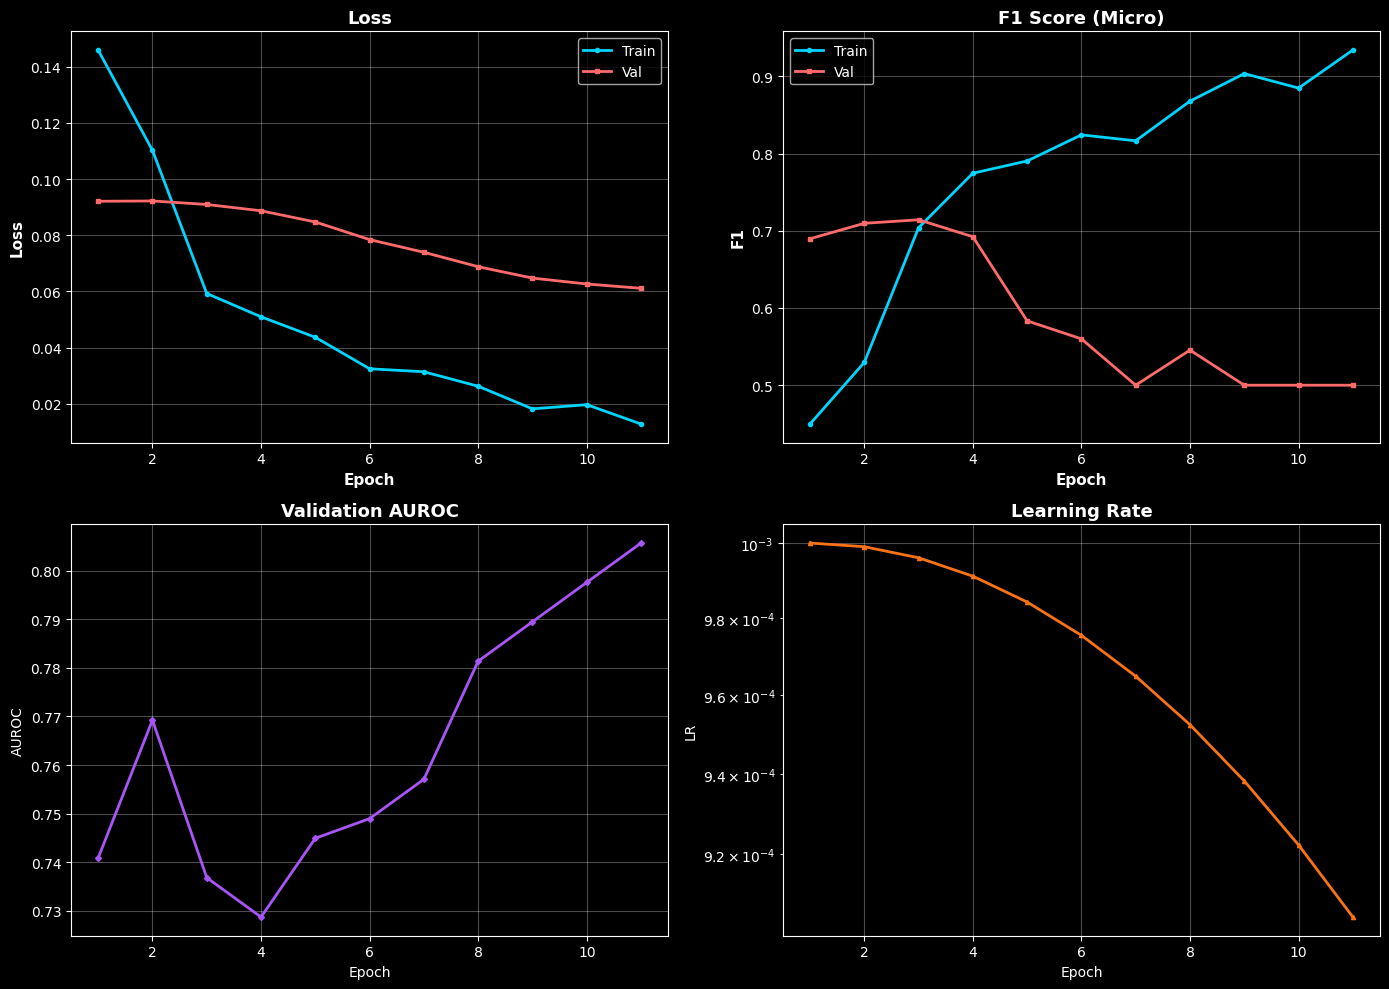

✅ Training curves saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)

for ax, k1, k2, title, ylabel in [
    (axes[0,0], 'train_loss', 'val_loss', 'Loss', 'Loss'),
    (axes[0,1], 'train_f1', 'val_f1', 'F1 Score (Micro)', 'F1'),
]:
    ax.plot(ep, history[k1], color=COLORS[0], lw=2, marker='o', ms=3, label='Train')
    ax.plot(ep, history[k2], color=COLORS[1], lw=2, marker='s', ms=3, label='Val')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

axes[1,0].plot(ep, history['val_auroc'], color=COLORS[4], lw=2, marker='D', ms=3)
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('AUROC')
axes[1,0].set_title('Validation AUROC', fontsize=13, fontweight='bold'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, history['lr'], color=COLORS[5], lw=2, marker='^', ms=3)
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('LR'); axes[1,1].set_yscale('log')
axes[1,1].set_title('Learning Rate', fontsize=13, fontweight='bold'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Training curves saved!')

---
### ✅ Training Complete!
**Next →** Open `04_evaluate_and_results.ipynb`